# Standard Cost Comparison for PVC
Plan is to update current standard costs to have a standardized formula below.<br>
new_std_cost = avg_cost × (1 + markup)<br>
Question is by how much? Need to determine if a 25%, 30%, or 35% increase over average cost would be best.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('std_cost_comparison_pvc_costs.tsv', sep='\t')
df.head()

,item_no,item_desc_1,item_desc_2,last_cost,avg_cost,std_cost
0,30100122840APET,APET,.012 x 28 x 40,1.50,1.50,4.04
1,3010015250523,PVC SHEET CLEAR,.015X25X52,0.00,0.00,3.01
2,301002860096ACR,PVC/ACRILIC ALLOY HAIRCELL 1 S,.028 X 60 X 96 BLACK # 4335,25.08,25.08,36.85
3,3010030480961,PVC SHEET GRAY,.032 50.5 X 99.5 TYPE I,65.32,63.79,71.84
4,3010060210519,PVC SHEET BLACK,".060 x 21"" x 51""",9.67,9.67,24.53


## Cleaning

Check rows for outliers that will interfere with the formulas (average or standard costs = 0) these will be flagged for review.

In [5]:
df['avg_cost_missing'] = df['avg_cost'] == 0
df['std_cost_missing'] = df['std_cost'] == 0
print(f'Number of Rows Where Average is 0 = {df["avg_cost_missing"].sum()}')
print(f'Number of Rows Where Standard = 0: {df["std_cost_missing"].sum()}')
print(f'Number of Rows Good = {(~df["avg_cost_missing"] & ~df["std_cost_missing"]).sum()}')

Number of Rows Where Average is 0 = 18
Number of Rows Where Standard = 0: 8
Number of Rows Good = 147


## Apply Formulas

In [6]:
markups = [0.25, 0.30, 0.35]

for m in markups:
    pct = int(m * 100)
    df[f'new_std_{pct}'] = df['avg_cost'] * (1 + m)
    df[f'diff_{pct}']    = df[f'new_std_{pct}'] - df['std_cost']
    df[f'pct_change_{pct}'] = np.where(df['std_cost'] == 0, np.nan, (df[f'new_std_{pct}'] - df['std_cost']) / df['std_cost'])

df.head(10)

,item_no,item_desc_1,item_desc_2,last_cost,avg_cost,std_cost,avg_cost_missing,std_cost_missing,new_std_25,diff_25,pct_change_25,new_std_30,diff_30,pct_change_30,new_std_35,diff_35,pct_change_35
0,30100122840APET,APET,.012 x 28 x 40,1.50,1.50,4.04,False,False,1.8750,-2.1650,-0.535891,1.950,-2.090,-0.517327,2.0250,-2.0150,-0.498762
1,3010015250523,PVC SHEET CLEAR,.015X25X52,0.00,0.00,3.01,True,False,0.0000,-3.0100,-1.000000,0.000,-3.010,-1.000000,0.0000,-3.0100,-1.000000
2,301002860096ACR,PVC/ACRILIC ALLOY HAIRCELL 1 S,.028 X 60 X 96 BLACK # 4335,25.08,25.08,36.85,False,False,31.3500,-5.5000,-0.149254,32.604,-4.246,-0.115224,33.8580,-2.9920,-0.081194
3,3010030480961,PVC SHEET GRAY,.032 50.5 X 99.5 TYPE I,65.32,63.79,71.84,False,False,79.7375,7.8975,0.109932,82.927,11.087,0.154329,86.1165,14.2765,0.198726
4,3010060210519,PVC SHEET BLACK,".060 x 21"" x 51""",9.67,9.67,24.53,False,False,12.0875,-12.4425,-0.507236,12.571,-11.959,-0.487525,13.0545,-11.4755,-0.467815
5,3010060210519,PVC SHEET BLACK,".060 x 21"" x 51""",0.00,0.00,23.36,True,False,0.0000,-23.3600,-1.000000,0.000,-23.360,-1.000000,0.0000,-23.3600,-1.000000
6,3010060480961,PVC SHEET GRAY,.060 X 48 X 96 TYPE I,24.70,24.85,41.09,False,False,31.0625,-10.0275,-0.244037,32.305,-8.785,-0.213799,33.5475,-7.5425,-0.183560
7,3010060480962,PVC SHEET WHITE,.060 48X96 TYPE I,14.25,14.75,26.81,False,False,18.4375,-8.3725,-0.312290,19.175,-7.635,-0.284782,19.9125,-6.8975,-0.257273
8,3010060480963,PVC SHEET CLEAR,.060 48 X 96 TYPE I,25.05,28.42,79.87,False,False,35.5250,-44.3450,-0.555215,36.946,-42.924,-0.537423,38.3670,-41.5030,-0.519632
9,3010060480967,PCV SHEET GRAY,.060 48 X 96 TYPE 2,20.68,19.44,44.57,False,False,24.3000,-20.2700,-0.454790,25.272,-19.298,-0.432982,26.2440,-18.3260,-0.411173


## Output Table

In [15]:
cols = ['item_no', 'item_desc_1', 'item_desc_2', 'avg_cost', 'std_cost', 'new_std_25', 'diff_25', 'pct_change_25', 'new_std_30', 'diff_30', 'pct_change_30', 'new_std_35', 'diff_35', 'pct_change_35', 'avg_cost_missing', 'std_cost_missing']

comparison = df[cols].copy()
comparison.style.format({'avg_cost': '${:,.2f}', 'std_cost': '${:,.2f}', 'new_std_25': '${:,.2f}', 'new_std_30': '${:,.2f}', 'new_std_35': '${:,.2f}', 
                         'diff_25': '${:,.2f}', 'diff_30': '${:,.2f}', 'diff_35': '${:,.2f}', 'pct_change_25': '{:.1%}', 'pct_change_30': '{:.1%}', 'pct_change_35': '{:.1%}',})

,item_no,item_desc_1,item_desc_2,avg_cost,std_cost,new_std_25,diff_25,pct_change_25,new_std_30,diff_30,pct_change_30,new_std_35,diff_35,pct_change_35,avg_cost_missing,std_cost_missing
0,30100122840APET,APET,.012 x 28 x 40,$1.50,$4.04,$1.88,$-2.17,-53.6%,$1.95,$-2.09,-51.7%,$2.03,$-2.01,-49.9%,False,False
1,3010015250523,PVC SHEET CLEAR,.015X25X52,$0.00,$3.01,$0.00,$-3.01,-100.0%,$0.00,$-3.01,-100.0%,$0.00,$-3.01,-100.0%,True,False
2,301002860096ACR,PVC/ACRILIC ALLOY HAIRCELL 1 S,.028 X 60 X 96 BLACK # 4335,$25.08,$36.85,$31.35,$-5.50,-14.9%,$32.60,$-4.25,-11.5%,$33.86,$-2.99,-8.1%,False,False
3,3010030480961,PVC SHEET GRAY,.032 50.5 X 99.5 TYPE I,$63.79,$71.84,$79.74,$7.90,11.0%,$82.93,$11.09,15.4%,$86.12,$14.28,19.9%,False,False
4,3010060210519,PVC SHEET BLACK,".060 x 21"" x 51""",$9.67,$24.53,$12.09,$-12.44,-50.7%,$12.57,$-11.96,-48.8%,$13.05,$-11.48,-46.8%,False,False
5,3010060210519,PVC SHEET BLACK,".060 x 21"" x 51""",$0.00,$23.36,$0.00,$-23.36,-100.0%,$0.00,$-23.36,-100.0%,$0.00,$-23.36,-100.0%,True,False
6,3010060480961,PVC SHEET GRAY,.060 X 48 X 96 TYPE I,$24.85,$41.09,$31.06,$-10.03,-24.4%,$32.30,$-8.79,-21.4%,$33.55,$-7.54,-18.4%,False,False
7,3010060480962,PVC SHEET WHITE,.060 48X96 TYPE I,$14.75,$26.81,$18.44,$-8.37,-31.2%,$19.18,$-7.63,-28.5%,$19.91,$-6.90,-25.7%,False,False
8,3010060480963,PVC SHEET CLEAR,.060 48 X 96 TYPE I,$28.42,$79.87,$35.53,$-44.34,-55.5%,$36.95,$-42.92,-53.7%,$38.37,$-41.50,-52.0%,False,False
9,3010060480967,PCV SHEET GRAY,.060 48 X 96 TYPE 2,$19.44,$44.57,$24.30,$-20.27,-45.5%,$25.27,$-19.30,-43.3%,$26.24,$-18.33,-41.1%,False,False


## Clean Output
Filter out rows where average and standard cost - 0.

In [14]:
valid = df[(~df['avg_cost_missing']) & (~df['std_cost_missing'])].copy()
print(f'{len(valid)} Good Rows Out of {len(df)}')
rows = []
for m in markups:
    pct = int(m * 100)
    diff = valid[f'diff_{pct}']
    pct_change = valid[f'pct_change_{pct}']
    rows.append({'scenario': f'{pct}% Above Average Cost', 'items_higher': int((diff > 0).sum()), 'items_lower': int((diff < 0).sum()), 'items_unchanged': int((diff == 0).sum()),
        'mean_diff': diff.mean(), 'median_diff': diff.median(), 'total_diff': diff.sum(), 'mean_pct_change': pct_change.mean(),})

summary = pd.DataFrame(rows)
summary.style.format({'mean_diff': '${:,.2f}', 'median_diff': '${:,.2f}', 'total_diff': '${:,.2f}', 'mean_pct_change': '{:.1%}',})

147 Good Rows Out of 171


,scenario,items_higher,items_lower,items_unchanged,mean_diff,median_diff,total_diff,mean_pct_change
0,25% Above Average Cost,21,126,0,$-87.60,$-8.37,"$-12,877.52",-19.5%
1,30% Above Average Cost,24,123,0,$-79.32,$-5.85,"$-11,659.34",-16.2%
2,35% Above Average Cost,31,116,0,$-71.03,$-3.75,"$-10,441.16",-13.0%


## Regression Model

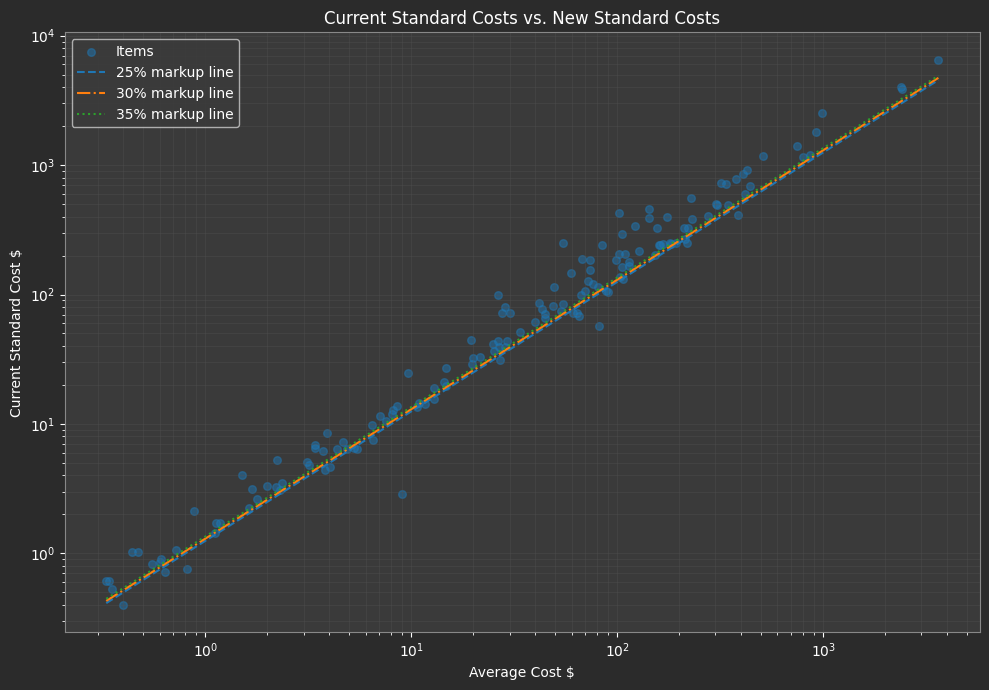

In [13]:
plt.rcParams['figure.facecolor'] = '#2b2b2b'
plt.rcParams['axes.facecolor'] = '#3a3a3a'
plt.rcParams['axes.edgecolor'] = '#888'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['text.color'] = 'white'
plt.rcParams['grid.color'] = '#555'
plt.rcParams['axes.titlecolor'] = 'white'

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(valid['avg_cost'], valid['std_cost'], alpha=0.5, s=30, label='Items')
x = np.linspace(valid['avg_cost'].min(), valid['avg_cost'].max(), 100)
for m, style in zip(markups, ['--', '-.', ':']):
    ax.plot(x, x * (1 + m), style, label=f'{int(m*100)}% markup line')
ax.set_xlabel('Average Cost $')
ax.set_ylabel('Current Standard Cost $')
ax.set_title('Current Standard Costs vs. New Standard Costs')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

Materials above the markup lines have current standard costs higher (unrealistic for pricing)<br>
Materials under the markup lines have lower current standard costs (possibly underpricing final sales).

### Materials w/ Current Standard Costs Under Lowest Markup (25%)
Return materials that have standard costs that are currently lower than the lowest planned markup.

In [22]:
above = valid[valid['diff_25'] > 0].sort_values('diff_25', ascending=False)
print(f'Items Where 25% Markup > Current Standard = {len(above)} Out of {len(valid)}')
above[['item_no', 'item_desc_1', 'avg_cost', 'std_cost', 'new_std_25', 'diff_25']].head(20)

Items Where 25% Markup > Current Standard = 21 Out of 147


,item_no,item_desc_1,avg_cost,std_cost,new_std_25,diff_25
75,3010750480962,PVC SHEET WHITE TYPE I,387.58,410.69,484.4750,73.7850
160,302052500100,PVC ROD GRAY,81.33,57.58,101.6625,44.0825
68,301050048096USA,"1/2"" X 48"" X 96"" GREY PVC",217.90,251.67,272.3750,20.7050
17,3010125480962,PVC SHEET WHITE,65.42,68.73,81.7750,13.0450
73,301075024048USA,"3/4"" X 24"" X 48"" GREY PVC",89.74,103.65,112.1750,8.5250
107,302006250200,5/8 PVC HEX ROD,8.99,2.89,11.2375,8.3475
3,3010030480961,PVC SHEET GRAY,63.79,71.84,79.7375,7.8975
157,302045000100,PVC ROD GRAY,61.07,71.61,76.3375,4.7275
34,3010187480962,PVC SHEET WHITE TYPE I,88.32,106.63,110.4000,3.7700
10,301006048096USA,.060 X 48 X 96 GREY PVC,26.92,31.09,33.6500,2.5600
